In [7]:
import numpy as np
import pandas as pd

# ============================================================
# 1. Load GDSC data
# ============================================================
# Change this to your actual file path
file_path = r"C:\Users\cdmas\Desktop\archive\GDSC_DATASET.csv"

df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print(df.columns.tolist())

# ============================================================
# 2. Keep only the columns we need
# ============================================================
needed_cols = [
    "CELL_LINE_NAME",
    "DRUG_ID",
    "DRUG_NAME",
    "LN_IC50",
    "TCGA_DESC",         
    "TARGET_PATHWAY"     
]

df = df[needed_cols].copy()

# Drop rows with missing critical values
df = df.dropna(subset=["CELL_LINE_NAME", "DRUG_ID", "LN_IC50", "TCGA_DESC", "TARGET_PATHWAY"])

print("After dropping NA:", df.shape)

# ============================================================
# 3. Make sure drug id is treated consistently
# ============================================================
df["DRUG_ID"] = df["DRUG_ID"].astype(str)

# Optional: remove duplicated cell line-drug pairs if any
# If duplicates exist, average LN_IC50
df = (
    df.groupby(["CELL_LINE_NAME", "DRUG_ID", "DRUG_NAME", "TCGA_DESC", "TARGET_PATHWAY"], as_index=False)
      .agg({"LN_IC50": "mean"})
)

print("After grouping duplicates:", df.shape)

# ============================================================
# 4. Build response matrix Y
# ============================================================
# Rows = cell lines, Columns = drugs
Y_df = df.pivot(index="CELL_LINE_NAME", columns="DRUG_ID", values="LN_IC50")

# Observation mask: 1 if observed, 0 otherwise
mask_df = Y_df.notna().astype(float)

# Fill missing values with 0 only for storage/computation;
# mask tells us which entries are actually observed
Y_filled_df = Y_df.fillna(0.0)

# Convert to numpy
Y = Y_filled_df.to_numpy(dtype=float)
mask = mask_df.to_numpy(dtype=float)

row_names = Y_df.index.tolist()
col_names = Y_df.columns.tolist()

print("Y shape:", Y.shape)
print("Mask observed fraction:", mask.mean())

# ============================================================
# 5. Build W: one row covariate per cell line
# ============================================================
# Since one cell line should have one TCGA_DESC, take first unique one
row_meta = (
    df[["CELL_LINE_NAME", "TCGA_DESC"]]
    .drop_duplicates(subset=["CELL_LINE_NAME"])
    .set_index("CELL_LINE_NAME")
)

# Reorder to match Y rows
row_meta = row_meta.loc[row_names]

# One-hot encode TCGA_DESC
W_df = pd.get_dummies(row_meta["TCGA_DESC"], prefix="TCGA", dtype=float)

W = W_df.to_numpy(dtype=float)

print("W shape:", W.shape)
print("W columns:", W_df.columns.tolist()[:10], "...")

# ============================================================
# 6. Build Z: one column covariate per drug
# ============================================================
# Since one drug should have one TARGET_PATHWAY, take first unique one
col_meta = (
    df[["DRUG_ID", "TARGET_PATHWAY"]]
    .drop_duplicates(subset=["DRUG_ID"])
    .set_index("DRUG_ID")
)

# Reorder to match Y columns
col_meta = col_meta.loc[col_names]

# One-hot encode TARGET_PATHWAY
Z_df = pd.get_dummies(col_meta["TARGET_PATHWAY"], prefix="PATH", dtype=float)

Z = Z_df.to_numpy(dtype=float)

print("Z shape:", Z.shape)
print("Z columns:", Z_df.columns.tolist()[:10], "...")

# ============================================================
# 7. Sanity checks
# ============================================================
n_rows, n_cols = Y.shape
assert W.shape[0] == n_rows, "W row dimension does not match Y"
assert Z.shape[0] == n_cols, "Z row dimension does not match Y columns"

print("\nFinal dimensions:")
print("Y:", Y.shape)
print("mask:", mask.shape)
print("W:", W.shape)
print("Z:", Z.shape)

# ============================================================
# 8. Optional: save processed arrays
# ============================================================
np.save("Y_gdsc.npy", Y)
np.save("mask_gdsc.npy", mask)
np.save("W_gdsc.npy", W)
np.save("Z_gdsc.npy", Z)

W_df.to_csv("W_features.csv")
Z_df.to_csv("Z_features.csv")
Y_df.to_csv("Y_matrix_with_nan.csv")
mask_df.to_csv("mask_matrix.csv")

print("\nSaved processed files.")

Original shape: (242035, 19)
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']
After dropping NA: (240968, 6)
After grouping duplicates: (240968, 6)
Y shape: (963, 295)
Mask observed fraction: 0.8482250030800641
W shape: (963, 32)
W columns: ['TCGA_ACC', 'TCGA_ALL', 'TCGA_BLCA', 'TCGA_BRCA', 'TCGA_CESC', 'TCGA_CLL', 'TCGA_COREAD', 'TCGA_DLBC', 'TCGA_ESCA', 'TCGA_GBM'] ...
Z shape: (295, 24)
Z columns: ['PATH_ABL signaling', 'PATH_Apoptosis regulation', 'PATH_Cell cycle', 'PATH_Chromatin histone acetylation', 'PATH_Chromatin histone methylation', 'PATH_Chromatin other', 'PATH_Cytoskeleton', 'PATH_DNA replication', 'PATH_EGFR signaling', 'PATH_ERK MAPK signaling'] ...

Final dimensions:
Y: (963, 295)
m

In [8]:
import numpy as np
import pandas as pd

# ============================================================
# Dense subset extraction from long-format GDSC data
# ============================================================

def extract_dense_subset(
    df,
    row_col="CELL_LINE_NAME",
    col_col="DRUG_ID",
    response_col="LN_IC50",
    row_feat_col="TCGA_DESC",
    col_feat_col="TARGET_PATHWAY",
    n_rows_keep=120,
    n_cols_keep=40,
    n_iter=5,
    verbose=True,
):
    """
    Extract a denser sub-dataset by iterative top-count filtering.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format table with one row per observed (cell line, drug) pair.
    row_col : str
        Row entity column, e.g. CELL_LINE_NAME.
    col_col : str
        Column entity column, e.g. DRUG_ID.
    response_col : str
        Response column, e.g. LN_IC50.
    row_feat_col : str
        Row covariate category, e.g. TCGA_DESC.
    col_feat_col : str
        Column covariate category, e.g. TARGET_PATHWAY.
    n_rows_keep : int
        Number of cell lines to keep.
    n_cols_keep : int
        Number of drugs to keep.
    n_iter : int
        Number of alternating filtering rounds.
    """

    use_cols = [row_col, col_col, response_col, row_feat_col, col_feat_col]
    df_sub = df[use_cols].copy()

    # Drop missing values
    df_sub = df_sub.dropna(subset=use_cols)

    # Make sure drug IDs are strings
    df_sub[col_col] = df_sub[col_col].astype(str)

    # Average duplicates if any
    df_sub = (
        df_sub.groupby([row_col, col_col, row_feat_col, col_feat_col], as_index=False)
              .agg({response_col: "mean"})
    )

    if verbose:
        print("Initial long-table shape:", df_sub.shape)
        n_rows0 = df_sub[row_col].nunique()
        n_cols0 = df_sub[col_col].nunique()
        print(f"Initial unique rows={n_rows0}, unique cols={n_cols0}")

    for t in range(n_iter):
        # top rows by count
        top_rows = df_sub[row_col].value_counts().index[:n_rows_keep]
        df_sub = df_sub[df_sub[row_col].isin(top_rows)].copy()

        # top cols by count after row restriction
        top_cols = df_sub[col_col].value_counts().index[:n_cols_keep]
        df_sub = df_sub[df_sub[col_col].isin(top_cols)].copy()

        if verbose:
            n_rows_now = df_sub[row_col].nunique()
            n_cols_now = df_sub[col_col].nunique()
            density_now = len(df_sub) / max(n_rows_now * n_cols_now, 1)
            print(
                f"Iter {t+1}: "
                f"rows={n_rows_now}, cols={n_cols_now}, "
                f"obs={len(df_sub)}, density={density_now:.4f}"
            )

    return df_sub

In [10]:
df_dense = extract_dense_subset(
    df,
    row_col="CELL_LINE_NAME",
    col_col="DRUG_ID",
    response_col="LN_IC50",
    row_feat_col="TCGA_DESC",
    col_feat_col="TARGET_PATHWAY",
    n_rows_keep=800,
    n_cols_keep=200,
    n_iter=6,
    verbose=True,
)

Initial long-table shape: (240968, 5)
Initial unique rows=963, unique cols=295
Iter 1: rows=800, cols=200, obs=155815, density=0.9738
Iter 2: rows=800, cols=200, obs=155815, density=0.9738
Iter 3: rows=800, cols=200, obs=155815, density=0.9738
Iter 4: rows=800, cols=200, obs=155815, density=0.9738
Iter 5: rows=800, cols=200, obs=155815, density=0.9738
Iter 6: rows=800, cols=200, obs=155815, density=0.9738


In [11]:
# ============================================================
# Build Y, mask, W, Z from dense subset
# ============================================================

# Pivot to matrix
Y_df = df_dense.pivot(index="CELL_LINE_NAME", columns="DRUG_ID", values="LN_IC50")

mask_df = Y_df.notna().astype(float)
Y_filled_df = Y_df.fillna(0.0)

Y = Y_filled_df.to_numpy(dtype=float)
mask = mask_df.to_numpy(dtype=float)

row_names = Y_df.index.tolist()
col_names = Y_df.columns.tolist()

print("Dense Y shape:", Y.shape)
print("Dense observed fraction:", mask.mean())

# Build W from TCGA_DESC
row_meta = (
    df_dense[["CELL_LINE_NAME", "TCGA_DESC"]]
    .drop_duplicates(subset=["CELL_LINE_NAME"])
    .set_index("CELL_LINE_NAME")
    .loc[row_names]
)

W_df = pd.get_dummies(row_meta["TCGA_DESC"], prefix="TCGA", dtype=float)
W = W_df.to_numpy(dtype=float)

# Build Z from TARGET_PATHWAY
col_meta = (
    df_dense[["DRUG_ID", "TARGET_PATHWAY"]]
    .drop_duplicates(subset=["DRUG_ID"])
    .set_index("DRUG_ID")
    .loc[col_names]
)

Z_df = pd.get_dummies(col_meta["TARGET_PATHWAY"], prefix="PATH", dtype=float)
Z = Z_df.to_numpy(dtype=float)

print("W shape:", W.shape)
print("Z shape:", Z.shape)

obs_vals = Y[mask == 1]
y_mean = obs_vals.mean()
y_std = obs_vals.std()

print("Observed mean:", y_mean)
print("Observed std :", y_std)

Y_std = Y.copy()
Y_std[mask == 1] = (Y_std[mask == 1] - y_mean) / (y_std + 1e-12)

Y = Y_std

def make_train_test_split(mask, train_ratio=0.8, seed=123):
    rng = np.random.default_rng(seed)
    obs_idx = np.argwhere(mask == 1)
    n_obs = len(obs_idx)
    n_train = int(train_ratio * n_obs)

    perm = rng.permutation(n_obs)
    train_idx = obs_idx[perm[:n_train]]
    test_idx = obs_idx[perm[n_train:]]

    mask_train = np.zeros_like(mask)
    mask_test = np.zeros_like(mask)

    for i, j in train_idx:
        mask_train[i, j] = 1.0
    for i, j in test_idx:
        mask_test[i, j] = 1.0

    return mask_train, mask_test

mask_train, mask_test = make_train_test_split(mask, train_ratio=0.8, seed=123)
Y_train = Y * mask_train

print("Train density:", mask_train.mean())
print("Test density :", mask_test.mean())

Dense Y shape: (800, 200)
Dense observed fraction: 0.97384375
W shape: (800, 31)
Z shape: (200, 24)
Observed mean: 2.8232589115168625
Observed std : 2.6229832568109415
Train density: 0.779075
Test density : 0.19476875


In [12]:
import numpy as np
import pandas as pd

# ============================================================
# 0. Utilities
# ============================================================

def fro_norm(X):
    return np.linalg.norm(X, ord="fro")

def svt(X, tau):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    s_shrunk = np.maximum(s - tau, 0.0)
    return (U * s_shrunk) @ Vt

def rmse_on_mask(Y_true, Y_pred, mask):
    denom = np.sum(mask)
    if denom == 0:
        return np.nan
    err = mask * (Y_true - Y_pred)
    return np.sqrt(np.sum(err**2) / denom)

def mae_on_mask(Y_true, Y_pred, mask):
    denom = np.sum(mask)
    if denom == 0:
        return np.nan
    err = np.abs(mask * (Y_true - Y_pred))
    return np.sum(err) / denom

def r2_on_mask(Y_true, Y_pred, mask):
    denom = np.sum(mask)
    if denom == 0:
        return np.nan
    y = Y_true[mask == 1]
    yhat = Y_pred[mask == 1]
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    if ss_tot <= 1e-12:
        return np.nan
    return 1.0 - ss_res / ss_tot

def pretty_metrics_row(name, Y_true, Y_pred, mask_train, mask_test):
    return {
        "Method": name,
        "Train RMSE": rmse_on_mask(Y_true, Y_pred, mask_train),
        "Test RMSE": rmse_on_mask(Y_true, Y_pred, mask_test),
        "Train MAE": mae_on_mask(Y_true, Y_pred, mask_train),
        "Test MAE": mae_on_mask(Y_true, Y_pred, mask_test),
        "Train R2": r2_on_mask(Y_true, Y_pred, mask_train),
        "Test R2": r2_on_mask(Y_true, Y_pred, mask_test),
    }

def clip_array(X, clip_value=5.0):
    return np.clip(X, -clip_value, clip_value)

def sanitize_matrix(X):
    return np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)


# ============================================================
# 1. Model builders
# ============================================================

def compose_lowrank(L):
    return L

def compose_waz_l(W, Z, A, L):
    return W @ A @ Z.T + L

def compose_full(W, Z, A, B, C, L):
    return W @ A @ Z.T + W @ B.T + C @ Z.T + L


# ============================================================
# 2. Stable low-rank solver
# ============================================================

def solve_lowrank_only(
    Y_train,
    mask_train,
    Y_full,
    mask_test,
    lambda_L=0.3,
    eta_L=0.05,
    max_iter=300,
    tol=1e-6,
    grad_clip=5.0,
    verbose=True,
):
    n1, n2 = Y_train.shape
    p_obs = np.mean(mask_train)
    L = np.zeros((n1, n2))
    loss_hist = []

    for it in range(max_iter):
        D = L
        R = mask_train * (D - Y_train)

        grad_L = R / max(p_obs, 1e-12)
        grad_L = clip_array(grad_L, grad_clip)

        L_step = L - eta_L * grad_L
        L_step = sanitize_matrix(L_step)

        try:
            L_new = svt(L_step, eta_L * lambda_L)
        except np.linalg.LinAlgError:
            print(f"[LowRank] SVD failed at iter {it}")
            break

        resid = mask_train * (L_new - Y_train)
        nuc = np.sum(np.linalg.svd(L_new, compute_uv=False))
        loss = 0.5 / max(p_obs, 1e-12) * np.sum(resid**2) + lambda_L * nuc
        loss_hist.append(loss)

        rel_change = np.linalg.norm(L_new - L) / (np.linalg.norm(L) + 1e-10)
        L = L_new

        if verbose and (it % 20 == 0 or it == max_iter - 1):
            train_rmse = rmse_on_mask(Y_full, L, mask_train)
            test_rmse = rmse_on_mask(Y_full, L, mask_test)
            print(f"[LowRank] iter={it:4d} loss={loss:.6f} train_rmse={train_rmse:.6f} test_rmse={test_rmse:.6f}")

        if not np.isfinite(loss):
            print(f"[LowRank] Non-finite loss at iter {it}")
            break

        if rel_change < tol:
            print(f"[LowRank] Converged at iter {it}")
            break

    return {
        "L": L,
        "Y_hat": L,
        "loss_hist": loss_hist,
    }


# ============================================================
# 3. Revised WAZ + L solver
#    Increase significance of WAZ^T by:
#      - removing / (n1*n2)
#      - larger eta_A
#      - smaller eta_L
#      - larger lambda_L
# ============================================================

def solve_waz_l(
    Y_train,
    mask_train,
    Y_full,
    mask_test,
    W,
    Z,
    lambda_L=0.3,
    eta_A=5e-3,
    eta_L=0.05,
    max_iter=300,
    tol=1e-6,
    grad_clip=5.0,
    param_clip=10.0,
    verbose=True,
):
    n1, n2 = Y_train.shape
    d1 = W.shape[1]
    d2 = Z.shape[1]
    p_obs = np.mean(mask_train)

    A = np.zeros((d1, d2))
    L = np.zeros((n1, n2))
    loss_hist = []

    for it in range(max_iter):
        # ---- A update ----
        D = compose_waz_l(W, Z, A, L)
        R = mask_train * (D - Y_train)

        grad_A = (W.T @ R @ Z) / max(p_obs, 1e-12)
        grad_A = clip_array(grad_A, grad_clip)

        A = A - eta_A * grad_A
        A = clip_array(A, param_clip)
        A = sanitize_matrix(A)

        # ---- L update ----
        D = compose_waz_l(W, Z, A, L)
        R = mask_train * (D - Y_train)

        grad_L = R / max(p_obs, 1e-12)
        grad_L = clip_array(grad_L, grad_clip)

        L_step = L - eta_L * grad_L
        L_step = sanitize_matrix(L_step)

        try:
            L_new = svt(L_step, eta_L * lambda_L)
        except np.linalg.LinAlgError:
            print(f"[WAZ+L] SVD failed at iter {it}")
            break

        D_new = compose_waz_l(W, Z, A, L_new)
        resid = mask_train * (D_new - Y_train)
        nuc = np.sum(np.linalg.svd(L_new, compute_uv=False))
        loss = 0.5 / max(p_obs, 1e-12) * np.sum(resid**2) + lambda_L * nuc
        loss_hist.append(loss)

        rel_change = np.linalg.norm(L_new - L) / (np.linalg.norm(L) + 1e-10)
        L = L_new

        if verbose and (it % 20 == 0 or it == max_iter - 1):
            Y_hat = compose_waz_l(W, Z, A, L)
            train_rmse = rmse_on_mask(Y_full, Y_hat, mask_train)
            test_rmse = rmse_on_mask(Y_full, Y_hat, mask_test)
            print(f"[WAZ+L] iter={it:4d} loss={loss:.6f} train_rmse={train_rmse:.6f} test_rmse={test_rmse:.6f}")

        if not np.isfinite(loss):
            print(f"[WAZ+L] Non-finite loss at iter {it}")
            break

        if rel_change < tol:
            print(f"[WAZ+L] Converged at iter {it}")
            break

    Y_hat = compose_waz_l(W, Z, A, L)
    return {
        "A": A,
        "L": L,
        "Y_hat": Y_hat,
        "loss_hist": loss_hist,
    }


# ============================================================
# 4. Revised full solver
#    Increase significance of WAZ^T, WB^T, CZ^T by:
#      - removing / (n1*n2)
#      - larger eta_A, eta_B, eta_C
#      - smaller eta_L
#      - larger lambda_L
#      - optional warm start
# ============================================================

def solve_full_model(
    Y_train,
    mask_train,
    Y_full,
    mask_test,
    W,
    Z,
    lambda_L=0.3,
    eta_A=5e-3,
    eta_B=5e-3,
    eta_C=5e-3,
    eta_L=0.05,
    max_iter=400,
    tol=1e-6,
    grad_clip=5.0,
    param_clip=10.0,
    verbose=True,
    A_init=None,
    B_init=None,
    C_init=None,
    L_init=None,
):
    n1, n2 = Y_train.shape
    d1 = W.shape[1]
    d2 = Z.shape[1]
    p_obs = np.mean(mask_train)

    A = np.zeros((d1, d2)) if A_init is None else A_init.copy()
    B = np.zeros((n2, d1)) if B_init is None else B_init.copy()
    C = np.zeros((n1, d2)) if C_init is None else C_init.copy()
    L = np.zeros((n1, n2)) if L_init is None else L_init.copy()

    loss_hist = []

    for it in range(max_iter):
        # ---- A ----
        D = compose_full(W, Z, A, B, C, L)
        R = mask_train * (D - Y_train)
        grad_A = (W.T @ R @ Z) / max(p_obs, 1e-12)
        grad_A = clip_array(grad_A, grad_clip)
        A = A - eta_A * grad_A
        A = clip_array(A, param_clip)
        A = sanitize_matrix(A)

        # ---- B ----
        D = compose_full(W, Z, A, B, C, L)
        R = mask_train * (D - Y_train)
        grad_B = (R.T @ W) / max(p_obs, 1e-12)
        grad_B = clip_array(grad_B, grad_clip)
        B = B - eta_B * grad_B
        B = clip_array(B, param_clip)
        B = sanitize_matrix(B)

        # ---- C ----
        D = compose_full(W, Z, A, B, C, L)
        R = mask_train * (D - Y_train)
        grad_C = (R @ Z) / max(p_obs, 1e-12)
        grad_C = clip_array(grad_C, grad_clip)
        C = C - eta_C * grad_C
        C = clip_array(C, param_clip)
        C = sanitize_matrix(C)

        # ---- L ----
        D = compose_full(W, Z, A, B, C, L)
        R = mask_train * (D - Y_train)
        grad_L = R / max(p_obs, 1e-12)
        grad_L = clip_array(grad_L, grad_clip)

        L_step = L - eta_L * grad_L
        L_step = sanitize_matrix(L_step)

        try:
            L_new = svt(L_step, eta_L * lambda_L)
        except np.linalg.LinAlgError:
            print(f"[FULL] SVD failed at iter {it}")
            break

        D_new = compose_full(W, Z, A, B, C, L_new)
        resid = mask_train * (D_new - Y_train)
        s = np.linalg.svd(L_new, compute_uv=False)
        nuc = np.sum(s)
        loss = 0.5 / max(p_obs, 1e-12) * np.sum(resid**2) + lambda_L * nuc
        loss_hist.append(loss)

        rel_change = np.linalg.norm(L_new - L) / (np.linalg.norm(L) + 1e-10)
        L = L_new

        if verbose and (it % 20 == 0 or it == max_iter - 1):
            Y_hat = compose_full(W, Z, A, B, C, L)
            train_rmse = rmse_on_mask(Y_full, Y_hat, mask_train)
            test_rmse = rmse_on_mask(Y_full, Y_hat, mask_test)
            rank_est = np.sum(s > 1e-8)
            print(f"[FULL] iter={it:4d} loss={loss:.6f} train_rmse={train_rmse:.6f} test_rmse={test_rmse:.6f} rank(L)={rank_est}")

        if not np.isfinite(loss):
            print(f"[FULL] Non-finite loss at iter {it}")
            break

        if rel_change < tol:
            print(f"[FULL] Converged at iter {it}")
            break

    Y_hat = compose_full(W, Z, A, B, C, L)
    return {
        "A": A,
        "B": B,
        "C": C,
        "L": L,
        "Y_hat": Y_hat,
        "loss_hist": loss_hist,
    }


# ============================================================
# 5. Diagnostics
# ============================================================

def component_norm_summary_full(W, Z, A, B, C, L):
    WAZ = W @ A @ Z.T
    WBt = W @ B.T
    CZt = C @ Z.T
    return {
        "||WAZ^T||_F": fro_norm(WAZ),
        "||WB^T||_F": fro_norm(WBt),
        "||CZ^T||_F": fro_norm(CZt),
        "||L||_F": fro_norm(L),
        "||Y_hat||_F": fro_norm(WAZ + WBt + CZt + L),
    }

def component_norm_summary_waz_l(W, Z, A, L):
    WAZ = W @ A @ Z.T
    return {
        "||WAZ^T||_F": fro_norm(WAZ),
        "||L||_F": fro_norm(L),
        "||Y_hat||_F": fro_norm(WAZ + L),
    }

def residual_summary(Y_true, Y_pred, mask):
    idx = mask == 1
    err = np.abs(Y_true[idx] - Y_pred[idx])
    if err.size == 0:
        return {}
    return {
        "rmse": float(np.sqrt(np.mean((Y_true[idx] - Y_pred[idx]) ** 2))),
        "mae": float(np.mean(err)),
        "max_abs": float(np.max(err)),
        "median_abs": float(np.median(err)),
        "q90_abs": float(np.quantile(err, 0.90)),
        "q95_abs": float(np.quantile(err, 0.95)),
    }

def pairwise_prediction_difference(name1, Yhat1, name2, Yhat2, mask):
    idx = mask == 1
    diff = Yhat1[idx] - Yhat2[idx]
    return {
        "pair": f"{name1} vs {name2}",
        "rmse_diff": float(np.sqrt(np.mean(diff ** 2))),
        "mae_diff": float(np.mean(np.abs(diff))),
        "max_abs_diff": float(np.max(np.abs(diff))),
    }

def print_component_and_residual_diagnostics(Y, mask_train, mask_test, W, Z, res_lowrank, res_waz_l, res_full):
    print("\n================ COMPONENT DIAGNOSTICS ================\n")

    print("[Low-rank only]")
    print({"||L||_F": fro_norm(res_lowrank["L"])})

    print("\n[WAZ + L]")
    print(component_norm_summary_waz_l(W, Z, res_waz_l["A"], res_waz_l["L"]))

    print("\n[Full]")
    print(component_norm_summary_full(W, Z, res_full["A"], res_full["B"], res_full["C"], res_full["L"]))

    print("\n================ TRAIN RESIDUAL DIAGNOSTICS ================\n")
    print("Low-rank only:", residual_summary(Y, res_lowrank["Y_hat"], mask_train))
    print("WAZ + L     :", residual_summary(Y, res_waz_l["Y_hat"], mask_train))
    print("Full        :", residual_summary(Y, res_full["Y_hat"], mask_train))

    print("\n================ TEST RESIDUAL DIAGNOSTICS ================\n")
    print("Low-rank only:", residual_summary(Y, res_lowrank["Y_hat"], mask_test))
    print("WAZ + L     :", residual_summary(Y, res_waz_l["Y_hat"], mask_test))
    print("Full        :", residual_summary(Y, res_full["Y_hat"], mask_test))

    print("\n================ PAIRWISE PREDICTION DIFFERENCES ================\n")
    print("On train mask:")
    print(pairwise_prediction_difference("Low-rank", res_lowrank["Y_hat"], "WAZ+L", res_waz_l["Y_hat"], mask_train))
    print(pairwise_prediction_difference("Low-rank", res_lowrank["Y_hat"], "Full", res_full["Y_hat"], mask_train))
    print(pairwise_prediction_difference("WAZ+L", res_waz_l["Y_hat"], "Full", res_full["Y_hat"], mask_train))

    print("\nOn test mask:")
    print(pairwise_prediction_difference("Low-rank", res_lowrank["Y_hat"], "WAZ+L", res_waz_l["Y_hat"], mask_test))
    print(pairwise_prediction_difference("Low-rank", res_lowrank["Y_hat"], "Full", res_full["Y_hat"], mask_test))
    print(pairwise_prediction_difference("WAZ+L", res_waz_l["Y_hat"], "Full", res_full["Y_hat"], mask_test))


# ============================================================
# 6. Run models on dense subset
# ============================================================

lambda_L = 0.3

res_lowrank = solve_lowrank_only(
    Y_train=Y_train,
    mask_train=mask_train,
    Y_full=Y,
    mask_test=mask_test,
    lambda_L=lambda_L,
    eta_L=0.05,
    max_iter=300,
    tol=1e-6,
    grad_clip=5.0,
    verbose=True,
)

res_waz_l = solve_waz_l(
    Y_train=Y_train,
    mask_train=mask_train,
    Y_full=Y,
    mask_test=mask_test,
    W=W,
    Z=Z,
    lambda_L=lambda_L,
    eta_A=5e-3,
    eta_L=0.05,
    max_iter=300,
    tol=1e-6,
    grad_clip=5.0,
    param_clip=10.0,
    verbose=True,
)

# warm start full model from WAZ + L
res_full = solve_full_model(
    Y_train=Y_train,
    mask_train=mask_train,
    Y_full=Y,
    mask_test=mask_test,
    W=W,
    Z=Z,
    lambda_L=lambda_L,
    eta_A=5e-3,
    eta_B=5e-3,
    eta_C=5e-3,
    eta_L=0.05,
    max_iter=400,
    tol=1e-6,
    grad_clip=5.0,
    param_clip=10.0,
    verbose=True,
    A_init=res_waz_l["A"],
    B_init=None,
    C_init=None,
    L_init=res_waz_l["L"],
)

# ============================================================
# 7. Comparison table
# ============================================================

rows = []
rows.append(pretty_metrics_row("Low-rank only", Y, res_lowrank["Y_hat"], mask_train, mask_test))
rows.append(pretty_metrics_row("WAZ + L", Y, res_waz_l["Y_hat"], mask_train, mask_test))
rows.append(pretty_metrics_row("Full: WAZ + WB^T + CZ^T + L", Y, res_full["Y_hat"], mask_train, mask_test))

results_df = pd.DataFrame(rows)

for c in results_df.columns[1:]:
    results_df[c] = results_df[c].map(lambda x: np.round(x, 6))

print("\n================ Comparison Table ================\n")
print(results_df.to_string(index=False))

results_df.to_csv("gdsc_dense_model_comparison_reweighted.csv", index=False)

# ============================================================
# 8. Singular values of L
# ============================================================

for name, res in [
    ("Low-rank only", res_lowrank),
    ("WAZ + L", res_waz_l),
    ("Full", res_full),
]:
    s = np.linalg.svd(res["L"], compute_uv=False)
    print(f"\n{name} -- top 10 singular values of L:")
    print(np.round(s[:10], 6))

# ============================================================
# 9. Extra diagnostics
# ============================================================

print_component_and_residual_diagnostics(
    Y=Y,
    mask_train=mask_train,
    mask_test=mask_test,
    W=W,
    Z=Z,
    res_lowrank=res_lowrank,
    res_waz_l=res_waz_l,
    res_full=res_full,
)

[LowRank] iter=   0 loss=70301.604955 train_rmse=0.937063 test_rmse=0.995674
[LowRank] iter=  20 loss=5745.210390 train_rmse=0.252678 test_rmse=0.984600
[LowRank] iter=  40 loss=1193.612516 train_rmse=0.071205 test_rmse=0.973627
[LowRank] iter=  60 loss=867.881978 train_rmse=0.023466 test_rmse=0.962766
[LowRank] iter=  80 loss=839.840306 train_rmse=0.011480 test_rmse=0.952022
[LowRank] iter= 100 loss=832.853051 train_rmse=0.008714 test_rmse=0.941399
[LowRank] iter= 120 loss=827.439132 train_rmse=0.008082 test_rmse=0.930899
[LowRank] iter= 140 loss=822.226777 train_rmse=0.007945 test_rmse=0.920522
[LowRank] iter= 160 loss=817.119403 train_rmse=0.007932 test_rmse=0.910269
[LowRank] iter= 180 loss=812.110157 train_rmse=0.007950 test_rmse=0.900140
[LowRank] iter= 200 loss=807.198440 train_rmse=0.007977 test_rmse=0.890137
[LowRank] iter= 220 loss=802.384037 train_rmse=0.008006 test_rmse=0.880259
[LowRank] iter= 240 loss=797.666698 train_rmse=0.008035 test_rmse=0.870508
[LowRank] iter= 260 l

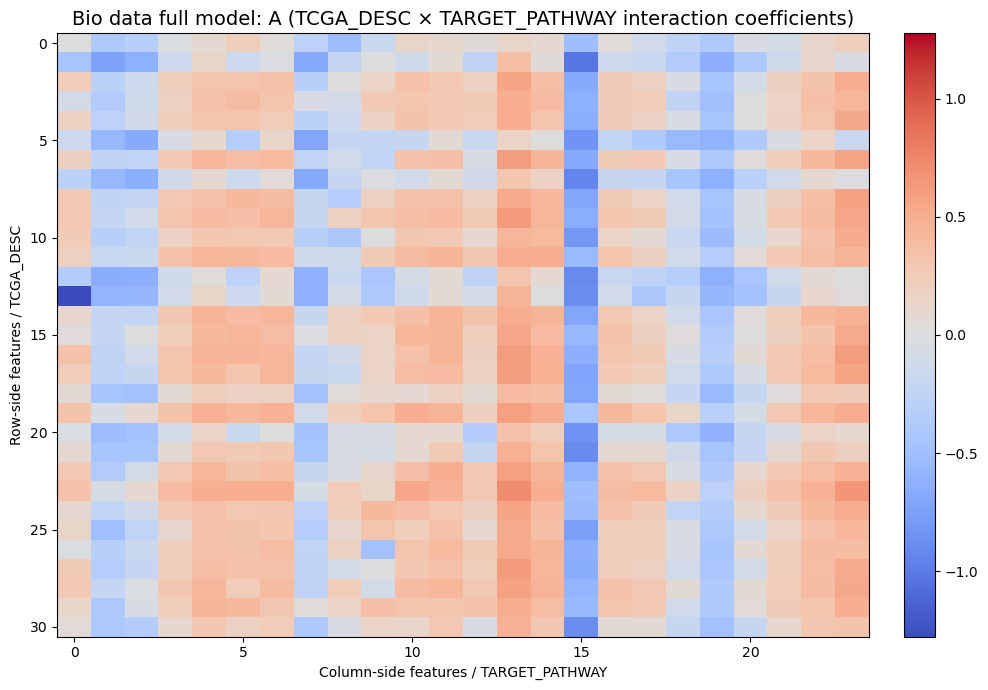

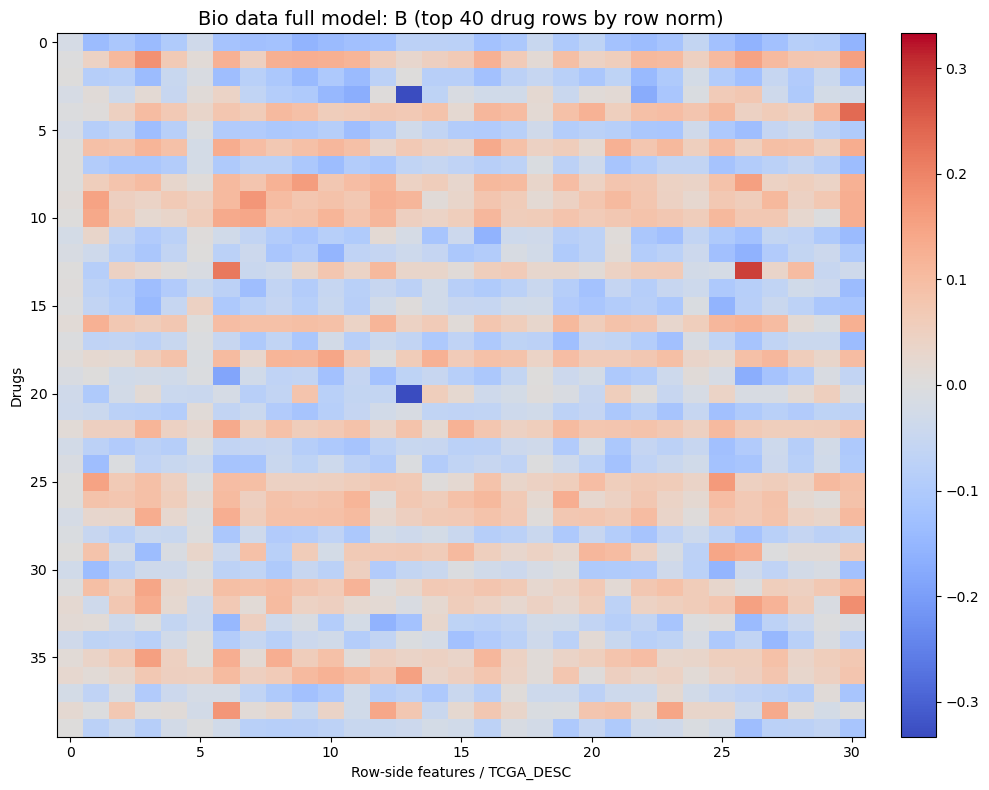

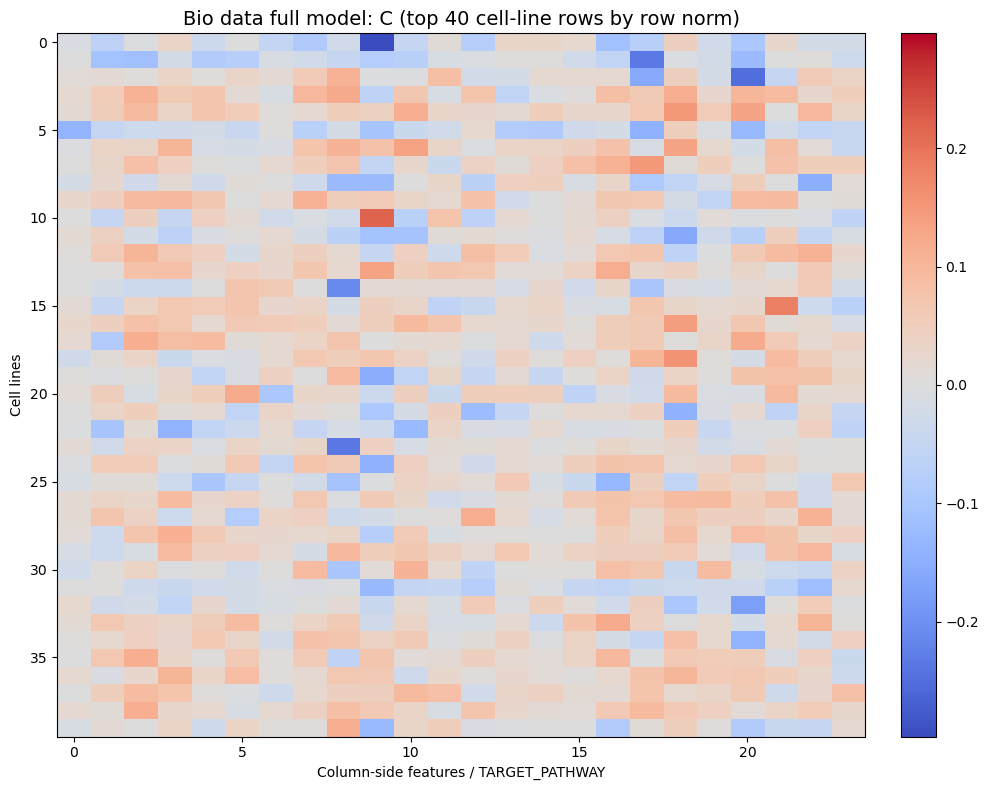

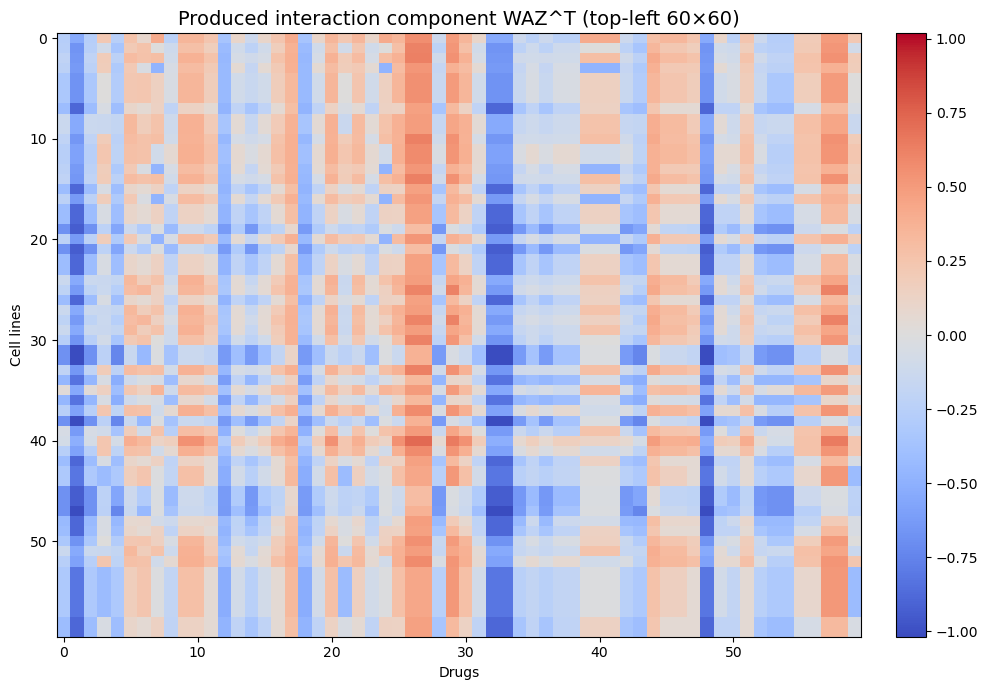

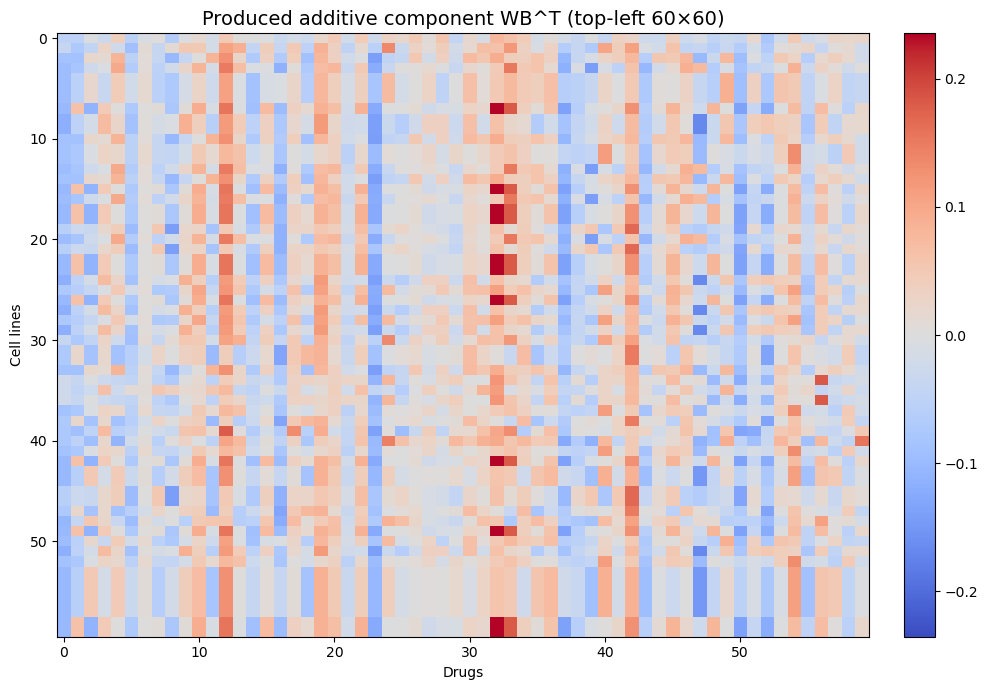

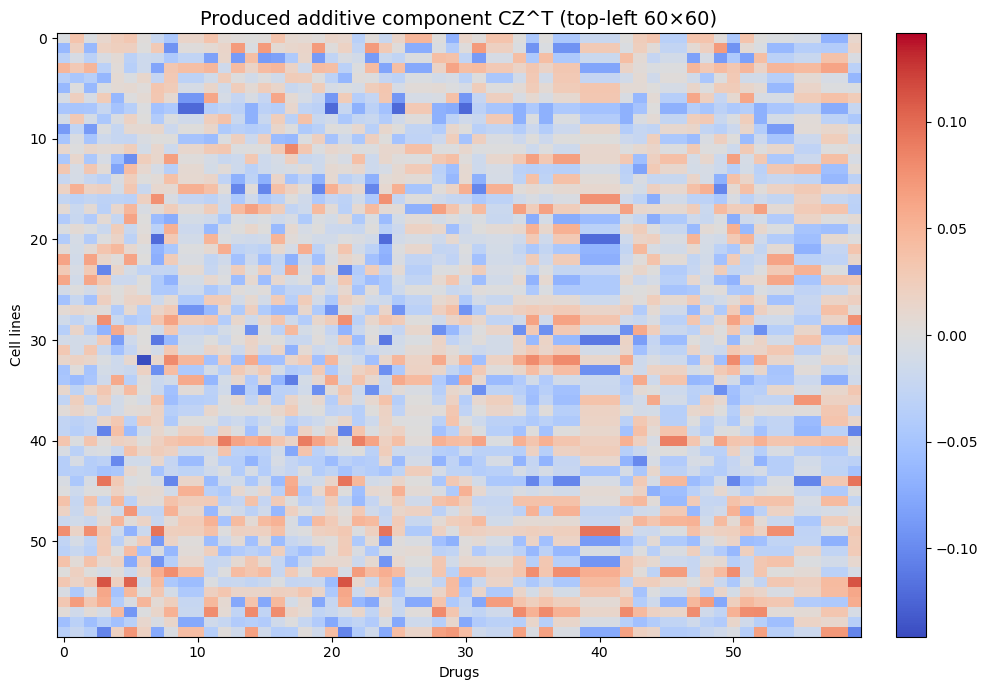

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Separate plotting code for BIO DATA full model
# Works with:
#   res_full["A"], res_full["B"], res_full["C"], res_full["L"]
#   W, Z
#
# Optional labels:
#   row_feature_names   : names of TCGA_DESC one-hot columns in W
#   col_feature_names   : names of TARGET_PATHWAY one-hot columns in Z
#   cell_line_names     : row names of Y
#   drug_names          : column names of Y
# ============================================================

def plot_heatmap(
    M,
    title,
    xlabel="Columns",
    ylabel="Rows",
    xtick_labels=None,
    ytick_labels=None,
    figsize=(8, 6),
    cmap="coolwarm",
    center_zero=True,
    annotate=False,
    fmt=".2f",
):
    plt.figure(figsize=figsize)

    if center_zero:
        vmax = np.max(np.abs(M))
        vmin = -vmax
    else:
        vmin = np.min(M)
        vmax = np.max(M)

    im = plt.imshow(M, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if xtick_labels is not None:
        plt.xticks(np.arange(len(xtick_labels)), xtick_labels, rotation=90)
    if ytick_labels is not None:
        plt.yticks(np.arange(len(ytick_labels)), ytick_labels)

    if annotate and M.shape[0] <= 20 and M.shape[1] <= 20:
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                plt.text(j, i, format(M[i, j], fmt), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


def top_rows_by_norm(M, k):
    row_norms = np.linalg.norm(M, axis=1)
    idx = np.argsort(row_norms)[::-1][:k]
    return idx, M[idx, :], row_norms[idx]


def plot_bio_full_model_ABC(
    res_full,
    W,
    Z,
    row_feature_names=None,   # TCGA_DESC feature names
    col_feature_names=None,   # TARGET_PATHWAY feature names
    cell_line_names=None,     # optional names of Y rows
    drug_names=None,          # optional names of Y cols
    top_k_B=40,
    top_k_C=40,
):
    A = res_full["A"]
    B = res_full["B"]
    C = res_full["C"]

    # --------------------------------------------------------
    # A: interaction coefficients
    # dimensions: d1 x d2
    # --------------------------------------------------------
    plot_heatmap(
        A,
        title="Bio data full model: A (TCGA_DESC × TARGET_PATHWAY interaction coefficients)",
        xlabel="Column-side features / TARGET_PATHWAY",
        ylabel="Row-side features / TCGA_DESC",
        xtick_labels=col_feature_names,
        ytick_labels=row_feature_names,
        figsize=(10, 7),
        cmap="coolwarm",
        center_zero=True,
        annotate=(A.shape[0] <= 15 and A.shape[1] <= 15),
    )

    # --------------------------------------------------------
    # B: drug-specific loadings on row-side features
    # dimensions: n_drugs x d1
    # rows = drugs, cols = row-side features
    # --------------------------------------------------------
    idx_B, B_plot, norms_B = top_rows_by_norm(B, min(top_k_B, B.shape[0]))

    if drug_names is not None:
        ylabels_B = [drug_names[i] for i in idx_B]
    else:
        ylabels_B = [f"drug_{i}" for i in idx_B]

    plot_heatmap(
        B_plot,
        title=f"Bio data full model: B (top {len(idx_B)} drug rows by row norm)",
        xlabel="Row-side features / TCGA_DESC",
        ylabel="Drugs",
        xtick_labels=row_feature_names,
        ytick_labels=ylabels_B if len(idx_B) <= 30 else None,
        figsize=(10, 8),
        cmap="coolwarm",
        center_zero=True,
        annotate=False,
    )

    # --------------------------------------------------------
    # C: cell-line-specific loadings on column-side features
    # dimensions: n_cell_lines x d2
    # rows = cell lines, cols = column-side features
    # --------------------------------------------------------
    idx_C, C_plot, norms_C = top_rows_by_norm(C, min(top_k_C, C.shape[0]))

    if cell_line_names is not None:
        ylabels_C = [cell_line_names[i] for i in idx_C]
    else:
        ylabels_C = [f"cell_{i}" for i in idx_C]

    plot_heatmap(
        C_plot,
        title=f"Bio data full model: C (top {len(idx_C)} cell-line rows by row norm)",
        xlabel="Column-side features / TARGET_PATHWAY",
        ylabel="Cell lines",
        xtick_labels=col_feature_names,
        ytick_labels=ylabels_C if len(idx_C) <= 30 else None,
        figsize=(10, 8),
        cmap="coolwarm",
        center_zero=True,
        annotate=False,
    )


# ============================================================
# Optional: plot the actual produced structured components
# Often more interpretable than raw A, B, C
# ============================================================

def plot_bio_full_model_components(
    res_full,
    W,
    Z,
    cell_line_names=None,
    drug_names=None,
    max_rows=60,
    max_cols=60,
):
    A = res_full["A"]
    B = res_full["B"]
    C = res_full["C"]

    WAZ = W @ A @ Z.T
    WBt = W @ B.T
    CZt = C @ Z.T

    def crop(M, max_rows=max_rows, max_cols=max_cols):
        return M[:min(M.shape[0], max_rows), :min(M.shape[1], max_cols)]

    plot_heatmap(
        crop(WAZ),
        title=f"Produced interaction component WAZ^T (top-left {min(WAZ.shape[0], max_rows)}×{min(WAZ.shape[1], max_cols)})",
        xlabel="Drugs",
        ylabel="Cell lines",
        figsize=(10, 7),
        cmap="coolwarm",
        center_zero=True,
    )

    plot_heatmap(
        crop(WBt),
        title=f"Produced additive component WB^T (top-left {min(WBt.shape[0], max_rows)}×{min(WBt.shape[1], max_cols)})",
        xlabel="Drugs",
        ylabel="Cell lines",
        figsize=(10, 7),
        cmap="coolwarm",
        center_zero=True,
    )

    plot_heatmap(
        crop(CZt),
        title=f"Produced additive component CZ^T (top-left {min(CZt.shape[0], max_rows)}×{min(CZt.shape[1], max_cols)})",
        xlabel="Drugs",
        ylabel="Cell lines",
        figsize=(10, 7),
        cmap="coolwarm",
        center_zero=True,
    )


# ============================================================
# Optional helper: build feature names if W and Z came from
# pd.get_dummies on TCGA_DESC and TARGET_PATHWAY
# Replace these with your actual lists if you already saved them
# ============================================================

# Example:
# row_feature_names = list(pd.get_dummies(row_meta["TCGA_DESC"], drop_first=False).columns)
# col_feature_names = list(pd.get_dummies(col_meta["TARGET_PATHWAY"], drop_first=False).columns)

# If you do not have names, just set them to None
row_feature_names = None
col_feature_names = None

# If you saved row/column identities from preprocessing, use them here
cell_line_names = None
drug_names = None


# ============================================================
# Example usage
# ============================================================

plot_bio_full_model_ABC(
    res_full=res_full,
    W=W,
    Z=Z,
    row_feature_names=row_feature_names,
    col_feature_names=col_feature_names,
    cell_line_names=cell_line_names,
    drug_names=drug_names,
    top_k_B=40,
    top_k_C=40,
)

# Optional: actual structured contribution matrices
plot_bio_full_model_components(
    res_full=res_full,
    W=W,
    Z=Z,
    cell_line_names=cell_line_names,
    drug_names=drug_names,
    max_rows=60,
    max_cols=60,
)